In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Set color palette
YEAR_COLORS = {2022: "#4E79A7", 2023: "#F28E2B", 2024: "#59A14F", 2025: "#E15759"}
ZONE_COLORS = {"Near Device": "#2196F3", "Pond Center": "#FF7043"}
sns.set_theme(style="whitegrid", font_scale=1.15)


In [2]:
LOGGER_URL = "https://raw.githubusercontent.com/GreenVaultJoe/capstone_Chrysler_Pond/refs/heads/main/data/cleaned_data/Master_Logger_Daily_2022_2025.csv"
SAMPLE_URL = "https://raw.githubusercontent.com/GreenVaultJoe/capstone_Chrysler_Pond/refs/heads/main/data/cleaned_data/Sample_results_2024_2025.csv"

# Load logger data
df_log = pd.read_csv(LOGGER_URL, parse_dates=["Timestamp"])
df_log = df_log.rename(columns={"Timestamp": "date", "DO_mgL": "do", "Temp_F": "temp"})
df_log["year"] = df_log["Year"].astype(int)
df_log["doy"]  = df_log["date"].dt.dayofyear

# Load lab sample data
df_raw = pd.read_csv(SAMPLE_URL)
print("Lab columns:", df_raw.columns.tolist())

Lab columns: ['Year', 'Sampling Date', 'Zone', 'Sample Label', 'Matrix', 'Depth (ft)', 'Parameter', 'Value', 'Units', 'Standard_Value', 'Standard_Units']


In [3]:
# Remove E. coli rows
df_raw = df_raw[df_raw["Parameter"] != "Escherichia Coli"]

# Map parameter names
PARAM_MAP = {
    "Total Phosphorus":"phosphorus",
    "Free Reactive Phosphorus":"phosphorus_reactive",
    "Total Nitrogen":"nitrogen",
    "Nitrogen, Kjeldahl, Total": "tkn",
    "TKN (as N)":"tkn",
    "Ammonia (as N)":"ammonia",
    "Nitrate (as N)":"nitrate",
    "Nitrogen, Nitrate (As N)":"nitrate",
    "Nitrite Nitrogen (As N)":"nitrite",
    "Nitrogen, Nitrite":"nitrite",
    "Chlorophyll A":"chlorophyll",
    "Turbidity":"turbidity",
    "Conductivity":"conductivity",
    "Percent Moisture":"pct_moisture",
}
df_raw["param_clean"] = df_raw["Parameter"].map(PARAM_MAP)

# Reshape to wide format
df_lab = (
    df_raw.dropna(subset=["param_clean"])
    .pivot_table(index=["Sampling Date", "Zone", "Year"],
                 columns="param_clean", values="Standard_Value", aggfunc="mean")
    .reset_index()
    .rename(columns={"Sampling Date": "date", "Zone": "zone", "Year": "year"})
)
df_lab.columns.name = None

# Fix date type
df_lab["date"] = pd.to_datetime(df_lab["date"])
df_lab["year"] = df_lab["year"].astype(int)

# Convert nutrients to mg/L
for col in ["phosphorus", "phosphorus_reactive", "nitrogen", "tkn", "ammonia", "nitrate", "nitrite"]:
    if col in df_lab.columns:
        df_lab[col] = df_lab[col] / 1000.0

# Save sampling dates for Plot 3
SAMPLE_DATES = sorted(df_lab["date"].dt.date.unique())

print("Lab data shape:", df_lab.shape)
print("Columns:", df_lab.columns.tolist())
print("Sampling dates:", SAMPLE_DATES)
print(df_lab[["date","zone","year","phosphorus","nitrogen","chlorophyll"]].to_string(index=False))

Lab data shape: (4, 14)
Columns: ['date', 'zone', 'year', 'ammonia', 'chlorophyll', 'conductivity', 'nitrate', 'nitrite', 'nitrogen', 'pct_moisture', 'phosphorus', 'phosphorus_reactive', 'tkn', 'turbidity']
Sampling dates: [datetime.date(2024, 6, 10), datetime.date(2025, 10, 1)]
      date        zone  year  phosphorus  nitrogen  chlorophyll
2025-10-01 Near Device  2025    0.014800   0.63000          0.0
2025-10-01 Pond Center  2025    0.380000   0.00966         33.4
2024-06-10 Near Device  2024    0.433667       NaN          NaN
2024-06-10 Pond Center  2024    0.338333       NaN          NaN


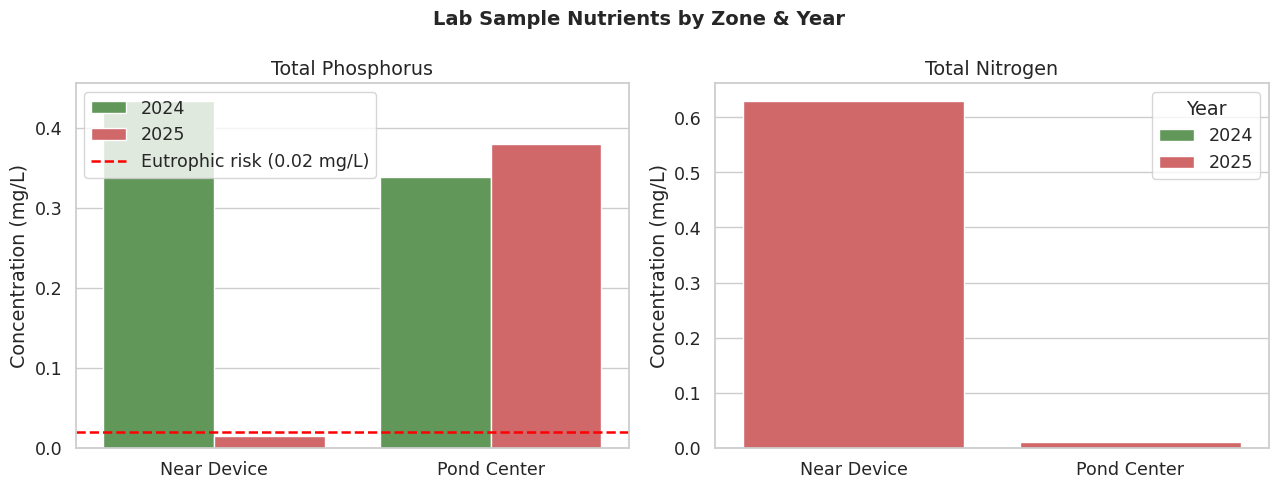

In [4]:
# Build bar chart data
rows = []
for _, r in df_lab.iterrows():
    for col, label in [("phosphorus","Total Phosphorus"), ("nitrogen","Total Nitrogen")]:
        if col in df_lab.columns and pd.notna(r.get(col)):
            rows.append({"Zone": r["zone"], "Year": str(int(r["year"])),
                         "Nutrient": label, "mg/L": r[col]})
plot1 = pd.DataFrame(rows)

# Draw one subplot per nutrient
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Lab Sample Nutrients by Zone & Year", fontsize=14, fontweight="bold")

for ax, nutrient in zip(axes, ["Total Phosphorus", "Total Nitrogen"]):
    data = plot1[plot1["Nutrient"] == nutrient]
    sns.barplot(data=data, x="Zone", y="mg/L", hue="Year",
            palette=[YEAR_COLORS[2024], YEAR_COLORS[2025]],
            hue_order=["2024", "2025"],  # Keep year order fixed
            order=["Near Device", "Pond Center"], ax=ax)
    if nutrient == "Total Phosphorus":
        ax.axhline(0.02, color="red", linestyle="--", linewidth=1.8,
                   label="Eutrophic risk (0.02 mg/L)")
        ax.legend()
    ax.set_title(nutrient)
    ax.set_ylabel("Concentration (mg/L)")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("plot1_nutrients.png", dpi=150, bbox_inches="tight")
plt.show()


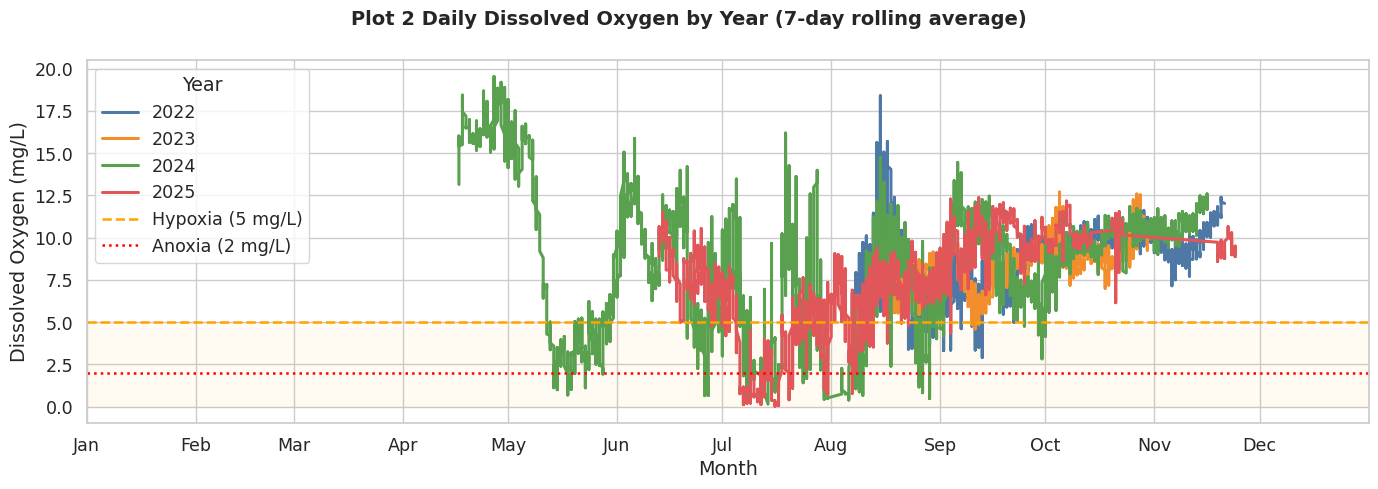

In [5]:
# Plot smoothed DO by year
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle("Plot 2 Daily Dissolved Oxygen by Year (7-day rolling average)",
             fontsize=14, fontweight="bold")

for year, color in YEAR_COLORS.items():
    yr = df_log[df_log["year"] == year].sort_values("doy").copy()
    if len(yr) == 0:
        continue
    yr["smooth"] = yr["do"].rolling(7, min_periods=1, center=True).mean()
    ax.plot(yr["doy"], yr["smooth"], color=color, linewidth=2.2, label=str(year))

# Add risk thresholds
ax.axhline(5, color="orange", linestyle="--", linewidth=1.8, label="Hypoxia (5 mg/L)")
ax.axhline(2, color="red",    linestyle=":",  linewidth=1.8, label="Anoxia (2 mg/L)")
ax.axhspan(0, 5, alpha=0.05, color="orange")

# Label months on the x-axis
ax.set_xticks([1,32,60,91,121,152,182,213,244,274,305,335])
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlim(1, 366)
ax.set_ylabel("Dissolved Oxygen (mg/L)")
ax.set_xlabel("Month")
ax.legend(title="Year")

plt.tight_layout()
plt.savefig("plot2_do_vitalsigns.png", dpi=150, bbox_inches="tight")
plt.show()


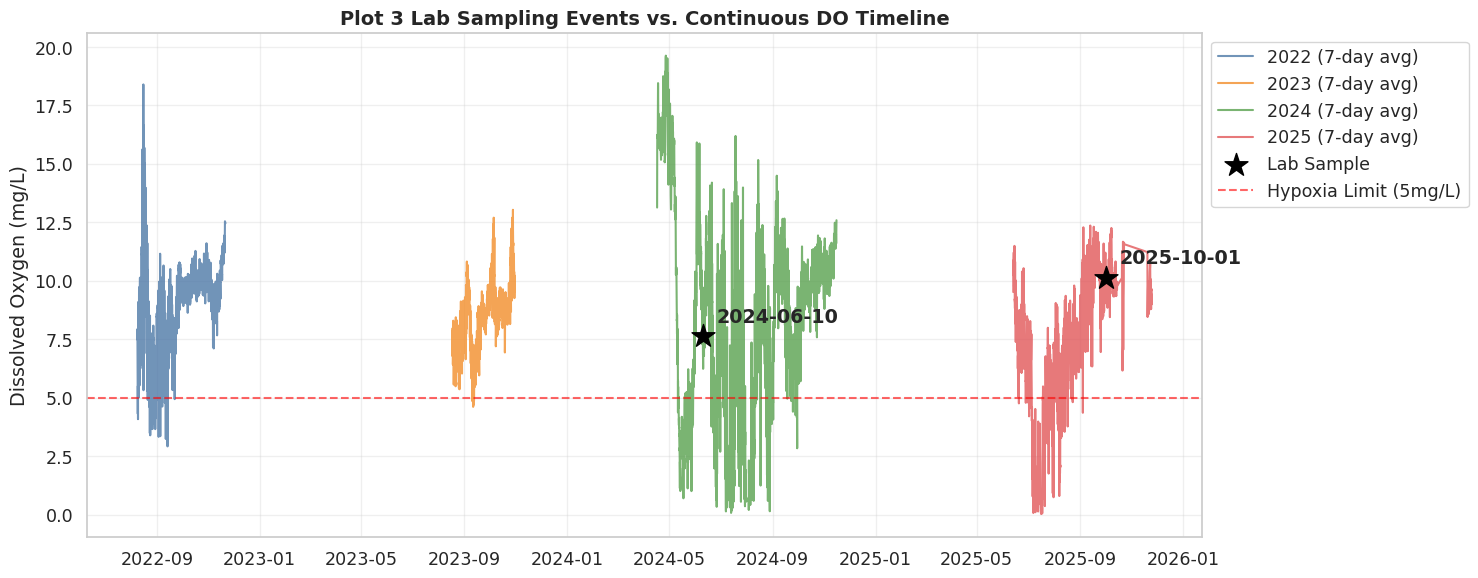

In [6]:
# Get DO values on sampling dates
sample_pts = []
for sdate in SAMPLE_DATES:
    match = df_log[df_log['date'].dt.date == sdate]
    if not match.empty:
        sample_pts.append({'date': pd.Timestamp(sdate), 'do': match['do'].mean()})
df_sample_pts = pd.DataFrame(sample_pts)

# Create the timeline plot
plt.figure(figsize=(15, 6))
plt.title("Plot 3 Lab Sampling Events vs. Continuous DO Timeline", fontsize=14, fontweight='bold')

# Plot each year
for year, color in YEAR_COLORS.items():
    yr_data = df_log[df_log['year'] == year].sort_values('date')
    if not yr_data.empty:
        plt.plot(yr_data['date'], yr_data['do'].rolling(7).mean(), color=color, label=f"{year} (7-day avg)", alpha=0.8)

# Mark sampling dates
for _, row in df_sample_pts.iterrows():
    plt.scatter(row['date'], row['do'], color='black', marker='*', s=300, zorder=5, label='Lab Sample' if _ == 0 else "")
    plt.annotate(row['date'].strftime('%Y-%m-%d'), (row['date'], row['do']), xytext=(10,10), textcoords='offset points', fontweight='bold')

plt.axhline(5, color='red', linestyle='--', alpha=0.6, label='Hypoxia Limit (5mg/L)')
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_simplified.png", dpi=150)
plt.show()

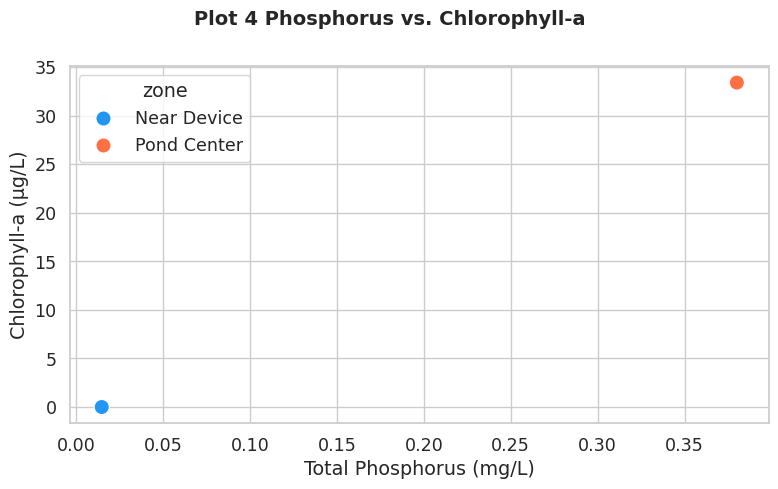

In [7]:
# Plot phosphorus vs. chlorophyll by zone
scatter = df_lab[["phosphorus","chlorophyll","zone"]].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Plot 4 Phosphorus vs. Chlorophyll-a", fontsize=14, fontweight="bold")

sns.scatterplot(data=scatter, x="phosphorus", y="chlorophyll",
                hue="zone", palette=list(ZONE_COLORS.values()),
                s=120, edgecolor="white", ax=ax)

# Add a regression line if possible
if len(scatter) >= 3:
    slope, intercept, r, p, _ = stats.linregress(scatter["phosphorus"], scatter["chlorophyll"])
    x = np.linspace(scatter["phosphorus"].min(), scatter["phosphorus"].max(), 100)
    ax.plot(x, slope * x + intercept, color="red", linestyle="--", linewidth=1.8,
            label=f"Trend  R²={r**2:.2f}")
    ax.legend()

ax.set_xlabel("Total Phosphorus (mg/L)")
ax.set_ylabel("Chlorophyll-a (µg/L)")

plt.tight_layout()
plt.savefig("plot4_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

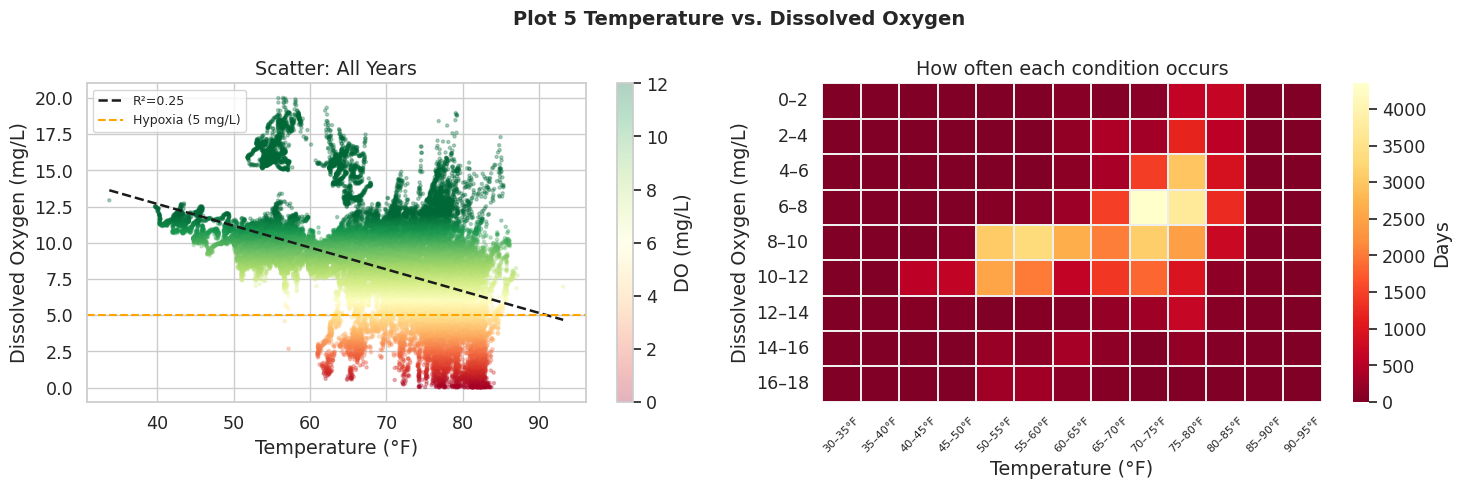

In [8]:
# Bin temperature and DO ranges
hm = df_log[["temp","do"]].dropna().copy()
hm["temp_bin"] = pd.cut(hm["temp"], bins=range(30, 105, 5),
                         labels=[f"{b}–{b+5}°F" for b in range(30, 100, 5)])
hm["do_bin"]   = pd.cut(hm["do"],   bins=range(0, 20, 2),
                         labels=[f"{b}–{b+2}" for b in range(0, 18, 2)])
pivot = hm.groupby(["do_bin","temp_bin"], observed=True).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Plot 5 Temperature vs. Dissolved Oxygen", fontsize=14, fontweight="bold")

# Left: scatter by DO level
sc = axes[0].scatter(hm["temp"], hm["do"], c=hm["do"], cmap="RdYlGn",
                     s=5, alpha=0.3, vmin=0, vmax=12)
plt.colorbar(sc, ax=axes[0], label="DO (mg/L)")
slope, intercept, r, _, _ = stats.linregress(hm["temp"], hm["do"])
x = np.linspace(hm["temp"].min(), hm["temp"].max(), 100)
axes[0].plot(x, slope*x + intercept, "k--", linewidth=1.8, label=f"R²={r**2:.2f}")
axes[0].axhline(5, color="orange", linestyle="--", linewidth=1.5, label="Hypoxia (5 mg/L)")
axes[0].set_xlabel("Temperature (°F)")
axes[0].set_ylabel("Dissolved Oxygen (mg/L)")
axes[0].set_title("Scatter: All Years")
axes[0].legend(fontsize=9)

# Right: frequency heatmap
sns.heatmap(pivot, cmap="YlOrRd_r", linewidths=0.3, linecolor="#EEE",
            cbar_kws={"label": "Days"}, ax=axes[1])
axes[1].set_title("How often each condition occurs")
axes[1].set_xlabel("Temperature (°F)")
axes[1].set_ylabel("Dissolved Oxygen (mg/L)")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

plt.tight_layout()
plt.savefig("plot5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Lab Samples:
 year        zone  phosphorus mean  phosphorus max  phosphorus min  nitrogen mean  nitrogen max  nitrogen min  chlorophyll mean  chlorophyll max  chlorophyll min
 2024 Near Device           0.4337          0.4337          0.4337            NaN           NaN           NaN               NaN              NaN              NaN
 2024 Pond Center           0.3383          0.3383          0.3383            NaN           NaN           NaN               NaN              NaN              NaN
 2025 Near Device           0.0148          0.0148          0.0148         0.6300        0.6300        0.6300               0.0              0.0              0.0
 2025 Pond Center           0.3800          0.3800          0.3800         0.0097        0.0097        0.0097              33.4             33.4             33.4

 Logger:
 year  do mean  do max  do min  temp mean  temp max  temp min
 2022     8.85   18.95    1.90      64.18     87.19     33.73
 2023     8.29   13.38    4.14      68.29  

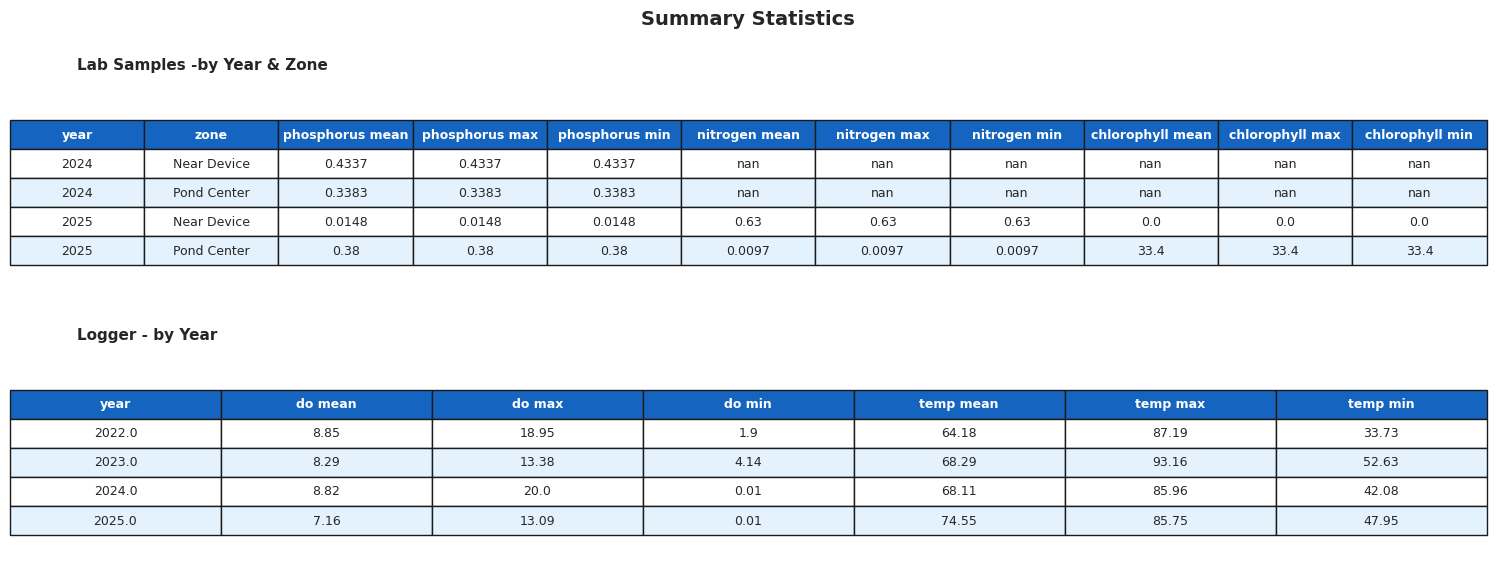

In [9]:
# Summarize lab data by year and zone
lab_cols = [c for c in ["phosphorus","nitrogen","chlorophyll"] if c in df_lab.columns]
lab_stats = df_lab.groupby(["year","zone"])[lab_cols].agg(["mean","max","min"]).round(4)
lab_stats.columns = [f"{c} {s}" for c, s in lab_stats.columns]
lab_stats = lab_stats.reset_index()

# Summarize logger data by year
log_stats = df_log.groupby("year")[["do","temp"]].agg(["mean","max","min"]).round(2)
log_stats.columns = [f"{c} {s}" for c, s in log_stats.columns]
log_stats = log_stats.reset_index()

print("Lab Samples:")
print(lab_stats.to_string(index=False))
print("\n Logger:")
print(log_stats.to_string(index=False))

# Draw both tables
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6))
fig.suptitle("Summary Statistics", fontsize=14, fontweight="bold")

for ax, df_t, title in [(ax1, lab_stats, "Lab Samples -by Year & Zone"),
                         (ax2, log_stats, "Logger - by Year")]:
    ax.axis("off")
    tbl = ax.table(cellText=df_t.values, colLabels=df_t.columns,
                   cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.1, 1.6)
    for j in range(len(df_t.columns)):
        tbl[(0,j)].set_facecolor("#1565C0")
        tbl[(0,j)].set_text_props(color="white", fontweight="bold")
    for i in range(1, len(df_t)+1):
        for j in range(len(df_t.columns)):
            tbl[(i,j)].set_facecolor("#E3F2FD" if i % 2 == 0 else "white")
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")

plt.tight_layout()
plt.savefig("summary_stats.png", dpi=150, bbox_inches="tight")
plt.show()